# EDA – Muskel-Segmentierung
Fokus: Label-Verteilung, Datenqualität und Eigenschaften relevant für Training eines Segmentierungsmodells.

**Analysiert:** Masken (`.nii.gz`), 35 Subjects. Water-Images sind lokal abgeschnitten → kein Intensitäts-Plot.

In [1]:
import os, re, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.0)

RESULTS  = Path('../results')
MASK_DIR = Path('../data/masks')
WATER_DIR = Path('../data/water')

# ── label mapping (primary: 1-8 = links, 9-12 = rechts quad; right-file: 9-16) ──
LABEL_NAMES = {
    0:  'BG',
    1:  'VL_L',   2:  'RF_L',   3:  'VM_L',   4:  'VI_L',
    5:  'BfSH_L', 6:  'BfLH_L', 7:  'ST_L',   8:  'SM_L',
    9:  'VL_R',   10: 'RF_R',   11: 'VM_R',   12: 'VI_R',
    13: 'BfSH_R', 14: 'BfLH_R', 15: 'ST_R',   16: 'SM_R',
}
MUSCLE_LABELS = list(range(1, 17))

def muscle_group(l):
    if l in range(1, 5):   return 'Quad L'
    if l in range(5, 9):   return 'Hamstr L'
    if l in range(9, 13):  return 'Quad R'
    if l in range(13, 17): return 'Hamstr R'
    return 'BG'

GROUP_COL = {'Quad L':'#4C72B0','Hamstr L':'#DD8452','Quad R':'#55A868','Hamstr R':'#C44E52'}
LABEL_COL  = {l: GROUP_COL[muscle_group(l)] for l in MUSCLE_LABELS}

def load_mask(path):
    """Return mask array; returns None if file is unreadable."""
    try:
        return np.asarray(nib.load(str(path)).dataobj)
    except Exception:
        return None

print('Setup ok.')

Setup ok.


---
## 1 · Datei-Inventar – welche IDs haben welche Masken?

In [2]:
records = []
for sid_dir in sorted(MASK_DIR.iterdir()):
    if not sid_dir.is_dir(): continue
    sid = sid_dir.name
    files = sorted(f for f in sid_dir.iterdir() if f.suffix == '.gz')
    for fp in files:
        img = nib.load(str(fp))
        arr = load_mask(fp)
        is_right = bool(re.search(r'right', fp.name, re.I))
        lbls = sorted(set(np.unique(arr).astype(int)) - {0}) if arr is not None else []
        records.append(dict(
            subject=sid, file=fp.name, is_right_file=is_right,
            shape=img.shape,
            vox_mm=tuple(np.round(img.header.get_zooms(), 3)),
            labels=lbls
        ))

inv = pd.DataFrame(records)
n_subjects = inv['subject'].nunique()
print(f'{n_subjects} Subjects, {len(inv)} Maskendateien')
inv[['subject','file','is_right_file','shape','vox_mm','labels']]

39 Subjects, 45 Maskendateien


,subject,file,is_right_file,shape,vox_mm,labels
0,501,"GCAP_501_cBO2,3_SP7,8_mask.nii.gz",False,"(704, 508, 626)","(0.653, 0.653, 2.0)","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
1,501,"GCAP_501_cBO2,3_SP7,8_mask_right.nii.gz",True,"(704, 508, 626)","(0.653, 0.653, 2.0)","[9, 10, 11, 12, 13, 14, 15, 16]"
2,502,GCAP_502_mask.nii.gz,False,"(704, 508, 626)","(0.653, 0.653, 2.0)","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
3,504,"GCAP_504_cBO2,3_SP7,8_mask.nii.gz",False,"(704, 508, 626)","(0.653, 0.653, 2.0)","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
4,504,"GCAP_504_cBO2,3_SP7,8_mask_right.nii.gz",True,"(704, 508, 626)","(0.653, 0.653, 2.0)","[9, 10, 11, 12, 13, 14, 15, 16]"
5,505,"GCAP_505_cBO2,3_SP7,8_mask.nii.gz",False,"(704, 508, 640)","(0.653, 0.653, 2.0)","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
6,506,"GCAP_506_cBO2,3_SP7,8_mask.nii.gz",False,"(704, 508, 640)","(0.653, 0.653, 2.0)","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
7,506,"GCAP_506_cBO2,3_SP7,8_rightmask.nii.gz",True,"(704, 508, 640)","(0.653, 0.653, 2.0)","[9, 10, 11, 12, 13, 14, 15, 16]"
8,507,"GCAP_507_cBO2,3_SP7,8_mask.nii.gz",False,"(704, 508, 640)","(0.653, 0.653, 2.0)","[1, 2, 3, 4, 5, 6, 7, 8]"
9,508,"GCAP_508_cBO2,3_SP7,8_mask.nii.gz",False,"(704, 508, 640)","(0.653, 0.653, 2.0)","[1, 2, 3, 4, 5, 6, 7, 8]"


**Was man sieht:** Eine Tabelle mit 45 Maskendateien von 39 Subjects. Jede Zeile ist eine `.nii.gz`-Datei mit Informationen zu Subject-ID, Dateiname, ob es eine Right-Datei ist, der Bildgrösse (Shape), der Voxelgrösse (vox\_mm) und den enthaltenen Label-IDs.

**Was das bedeutet:**
- Manche Subjects haben **zwei Dateien**: eine normale Maske (Labels 1–12) und eine `_right`-Datei (Labels 9–16), weil die rechte Seite separat annotiert wurde.
- Alle Bilder haben dieselbe Voxelgrösse `(0.653, 0.653, 2.0) mm` — das ist konsistent und gut für das Training.
- Die Dateinamen sind **nicht einheitlich** (z.B. `GCAP512mask.nii.gz` vs. `GCAP_512_mask.nii.gz`), was auf manuelle Annotation hindeutet und beim Laden beachtet werden muss.

---
## 2 · Welche Muskeln hat welche ID?

In [3]:
# Union über alle Dateien pro Subject
subj_lbls = {}
for sid, grp in inv.groupby('subject'):
    all_l = set()
    for row_lbls in grp['labels']:
        all_l.update(row_lbls)
    subj_lbls[sid] = sorted(all_l)

sids = sorted(subj_lbls.keys())

# Tabelle: Subject → Muskeln
rows = []
for sid in sids:
    left  = [LABEL_NAMES[l] for l in subj_lbls[sid] if l <= 8]
    right = [LABEL_NAMES[l] for l in subj_lbls[sid] if l >= 9]
    rows.append({'subject': sid,
                 'n_labels': len(subj_lbls[sid]),
                 'bilateral': 'Ja' if right else 'Nein',
                 'links': ', '.join(left),
                 'rechts': ', '.join(right) if right else '—'})

id_table = pd.DataFrame(rows)
print(id_table.to_string(index=False))

subject  n_labels bilateral                                              links                                             rechts
    501        16        Ja VL_L, RF_L, VM_L, VI_L, BfSH_L, BfLH_L, ST_L, SM_L VL_R, RF_R, VM_R, VI_R, BfSH_R, BfLH_R, ST_R, SM_R
    502        12        Ja VL_L, RF_L, VM_L, VI_L, BfSH_L, BfLH_L, ST_L, SM_L                             VL_R, RF_R, VM_R, VI_R
    504        16        Ja VL_L, RF_L, VM_L, VI_L, BfSH_L, BfLH_L, ST_L, SM_L VL_R, RF_R, VM_R, VI_R, BfSH_R, BfLH_R, ST_R, SM_R
    505        12        Ja VL_L, RF_L, VM_L, VI_L, BfSH_L, BfLH_L, ST_L, SM_L                             VL_R, RF_R, VM_R, VI_R
    506        16        Ja VL_L, RF_L, VM_L, VI_L, BfSH_L, BfLH_L, ST_L, SM_L VL_R, RF_R, VM_R, VI_R, BfSH_R, BfLH_R, ST_R, SM_R
    507         8      Nein VL_L, RF_L, VM_L, VI_L, BfSH_L, BfLH_L, ST_L, SM_L                                                  —
    508        16        Ja VL_L, RF_L, VM_L, VI_L, BfSH_L, BfLH_L, ST_L, SM_L VL_R, RF_R,

**Was man sieht:** Eine Tabelle mit einer Zeile pro Subject, die zeigt, wie viele Labels vorhanden sind, ob bilateral annotiert wurde, und welche Muskeln links bzw. rechts annotiert sind.

**Was das bedeutet:**
- **30 von 39 Subjects** haben nur die linke Seite annotiert (Labels 1–8).
- Nur **5 Subjects** (501, 504, 506, 508, 511) haben alle 16 Muskeln vollständig bilateral.
- **4 Subjects haben unvollständige Label-Sets** — das muss beim Training berücksichtigt werden:
  - 502, 505: Labels 1–12 (Quadrizeps + Hamstrings links, aber nur Quadrizeps rechts — Hamstrings rechts fehlen)
  - 524: Labels 1–9 (nur VL_R auf der rechten Seite)
  - 543: Labels 5–16 (Quadrizeps links fehlt komplett)

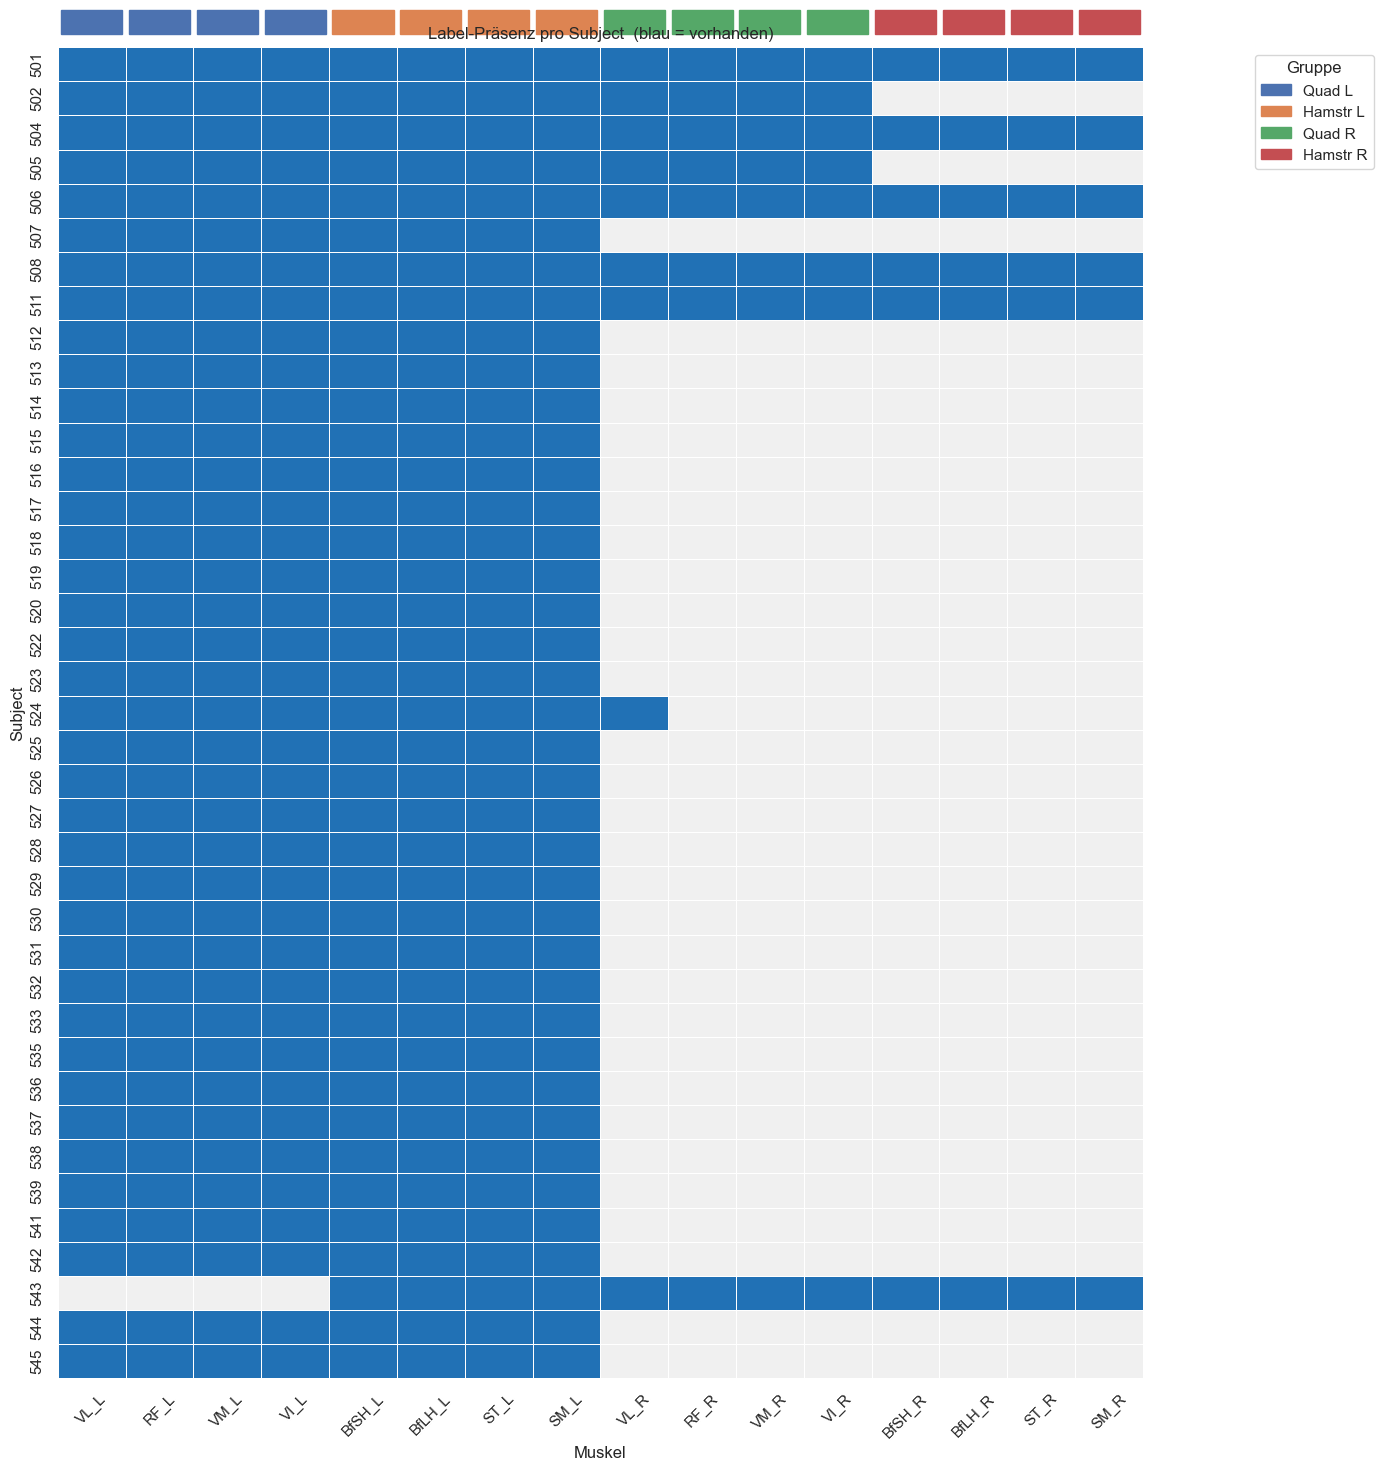

In [4]:
# Binärmatrix: Rows = Subjects, Cols = Muskeln
presence = pd.DataFrame(
    {sid: {LABEL_NAMES[l]: int(l in subj_lbls[sid]) for l in MUSCLE_LABELS}
     for sid in sids}
).T
presence.index.name = 'subject'

# Heatmap
fig, ax = plt.subplots(figsize=(14, max(5, len(sids) * 0.38)))
sns.heatmap(presence.astype(int), ax=ax, cmap=['#f0f0f0','#2171b5'],
            cbar=False, linewidths=0.4, linecolor='white')
ax.set_title('Label-Präsenz pro Subject  (blau = vorhanden)', fontsize=12)
ax.set_xlabel('Muskel')
ax.set_ylabel('Subject')
ax.tick_params(axis='x', rotation=45)

# Farbband unter den Spaltenbezeichnungen
for i, l in enumerate(MUSCLE_LABELS):
    ax.add_patch(mpatches.FancyBboxPatch(
        (i + 0.05, -1.1), 0.9, 0.7,
        boxstyle='square,pad=0',
        color=GROUP_COL[muscle_group(l)],
        transform=ax.transData, clip_on=False, zorder=3))

patches = [mpatches.Patch(color=c, label=g) for g, c in GROUP_COL.items()]
ax.legend(handles=patches, loc='upper right', bbox_to_anchor=(1.22, 1), title='Gruppe')
plt.tight_layout()
plt.savefig(RESULTS / 'eda_seg_presence_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

**Was man sieht:** Eine Heatmap mit Subjects als Zeilen und Muskeln als Spalten. Blaue Felder bedeuten, dass der Muskel für dieses Subject annotiert ist; graue Felder bedeuten, dass das Label fehlt. Die Farbbänder unter den Spaltennamen zeigen die Muskelgruppe (Blau = Quadrizeps links, Orange = Hamstrings links, Grün = Quadrizeps rechts, Rot = Hamstrings rechts).

**Was das bedeutet:**
- Man sieht auf einen Blick, dass die **rechte Hälfte der Heatmap** (Muskeln 9–16) für die meisten Subjects grau/leer ist — rechte Seite ist selten annotiert.
- Die **linken 8 Muskeln** (Labels 1–8) sind bei fast allen Subjects vollständig vorhanden.
- Subject 543 fällt auf: Die linken Quadrizeps-Muskeln (1–4, blau) fehlen — nur Hamstrings links und alle rechten Muskeln sind vorhanden.
- Diese Visualisierung ist wichtig für die **Train/Validation/Test-Aufteilung**: Man sollte bilateral annotierte Subjects gezielt verteilen, da sie seltener sind.

In [5]:
# Zusammenfassung bilateral vs. nur links
n_bi = (id_table['bilateral'] == 'Ja').sum()
print(f'Subjects gesamt       : {len(sids)}')
print(f'  Bilateral annotiert : {n_bi}')
print(f'  Nur links annotiert : {len(sids) - n_bi}')
print()
print('Subjects mit vollständig bilateral (alle 16 Label):')
full16 = [s for s in sids if len(subj_lbls[s]) == 16]
print(' ', full16 if full16 else 'keine')
print()
print('Subjects mit unvollständigem Label-Set (weder 8 noch 16):')
partial = [s for s in sids if len(subj_lbls[s]) not in (8, 16)]
for s in partial:
    print(f'  {s}: {subj_lbls[s]}')

Subjects gesamt       : 39
  Bilateral annotiert : 9
  Nur links annotiert : 30

Subjects mit vollständig bilateral (alle 16 Label):
  ['501', '504', '506', '508', '511']

Subjects mit unvollständigem Label-Set (weder 8 noch 16):
  502: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]
  505: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]
  524: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
  543: [np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16)]


**Was man sieht:** Eine Zusammenfassung, wie viele Subjects bilateral vs. nur links annotiert sind, welche Subjects alle 16 Labels haben und welche ein unvollständiges Label-Set besitzen.

**Was das bedeutet:**
- Nur **9 von 39 Subjects** sind bilateral annotiert — das ist eine starke Asymmetrie im Datensatz.
- Nur **5 Subjects** (501, 504, 506, 508, 511) haben das vollständige Set aus 16 Muskeln.
- Die **4 Subjects mit unvollständigem Label-Set** (502, 505, 524, 543) müssen beim Training entweder ausgeschlossen oder mit einer Strategie für fehlende Labels behandelt werden (z.B. diese Labels beim Loss ignorieren).

---
## 3 · Bildgeometrie – Shapes & Voxelgrössen

In [6]:
primary = inv[~inv['is_right_file']].copy()

shapes = pd.DataFrame(primary['shape'].tolist(),   columns=['X','Y','Z'], index=primary['subject'].values)
zooms  = pd.DataFrame(primary['vox_mm'].tolist(),  columns=['dx','dy','dz'], index=primary['subject'].values)

print('=== Shapes (Häufigkeit) ===')
print(shapes.value_counts().to_string())
print()
print('=== In-plane Voxelgrösse ===')
print(zooms[['dx','dy']].value_counts().to_string())
print()
print('=== Slice-Dicke (dz) ===')
print(zooms['dz'].value_counts().to_string())
print()
print('=== Z-Dim (# Schichten) ===')
print(shapes['Z'].describe().round(0))

=== Shapes (Häufigkeit) ===
X    Y    Z  
704  508  640    36
          626     3

=== In-plane Voxelgrösse ===
dx     dy   
0.653  0.653    39

=== Slice-Dicke (dz) ===
dz
2.0    39

=== Z-Dim (# Schichten) ===
count     39.0
mean     639.0
std        4.0
min      626.0
25%      640.0
50%      640.0
75%      640.0
max      640.0
Name: Z, dtype: float64


**Was man sieht:** Häufigkeitstabellen für Bildgrösse (Shape), In-plane Voxelgrösse und Schichtdicke sowie eine Statistik der Z-Dimension.

**Was das bedeutet:**
- **36 von 39 Subjects** haben exakt die gleiche Shape `(704, 508, 640)` — nur 3 haben 626 Schichten statt 640. Das ist sehr homogen.
- Die **In-plane Auflösung** ist bei allen identisch: `0.653 × 0.653 mm` — kein Resampling nötig.
- Die **Schichtdicke** ist bei allen `2.0 mm` — das ist anisotrop, d.h. die Auflösung in Z-Richtung ist ~3× gröber als in der Fläche. Das muss beim 3D-Netz beachtet werden (z.B. anisotrope Kernel oder 2D-Slicing-Ansatz).
- **Fazit:** Die Geometrie ist fast perfekt einheitlich — ideal für das Training ohne aufwändige Vorverarbeitung.

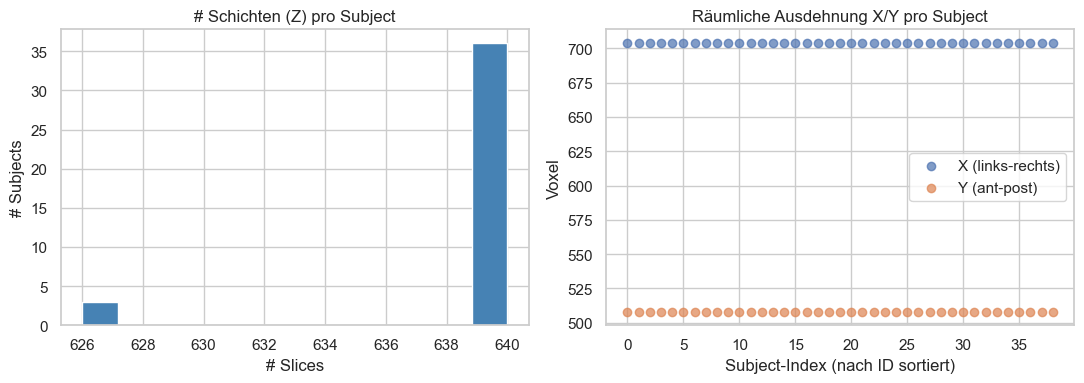

Voxelvolumen: [0.852818] mm³


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(shapes['Z'].values, bins=12, color='steelblue', edgecolor='white')
axes[0].set_title('# Schichten (Z) pro Subject')
axes[0].set_xlabel('# Slices');  axes[0].set_ylabel('# Subjects')

x_pos = range(len(shapes))
axes[1].scatter(x_pos, shapes['X'].values, label='X (links-rechts)', alpha=0.7)
axes[1].scatter(x_pos, shapes['Y'].values, label='Y (ant-post)', alpha=0.7)
axes[1].set_title('Räumliche Ausdehnung X/Y pro Subject')
axes[1].set_xlabel('Subject-Index (nach ID sortiert)')
axes[1].set_ylabel('Voxel')
axes[1].legend()

plt.tight_layout()
plt.savefig(RESULTS / 'eda_seg_geometry.png', dpi=150)
plt.show()

vox_vol = zooms['dx'] * zooms['dy'] * zooms['dz']
print(f'Voxelvolumen: {vox_vol.unique()} mm³')

**Was man sieht:** Links ein Histogramm der Anzahl Schichten (Z-Dimension) pro Subject; rechts ein Scatter-Plot der X- und Y-Ausdehnung in Voxeln pro Subject.

**Was das bedeutet:**
- Das **Histogramm** zeigt zwei Balken: fast alle Subjects haben 640 Schichten, 3 haben 626 — die Verteilung ist sehr eng, d.h. kaum Variabilität.
- Der **Scatter-Plot** zeigt, dass X (704) und Y (508) bei allen Subjects konstant sind — alle Punkte liegen exakt übereinander. Das bestätigt die perfekte Homogenität der Bildgrösse.
- Das Voxelvolumen beträgt `0.653 × 0.653 × 2.0 = 0.853 mm³` pro Voxel — konsistent über alle Subjects.

---
## 4 · Muskelvolumen pro Subject (Voxel & ml)

In [8]:
vol_rows = []
for sid_dir in sorted(MASK_DIR.iterdir()):
    if not sid_dir.is_dir(): continue
    sid = sid_dir.name
    files = sorted(f for f in sid_dir.iterdir() if f.suffix == '.gz')

    counts  = {l: 0 for l in MUSCLE_LABELS}
    zoom_mm3 = None
    for fp in files:
        img = nib.load(str(fp))
        if zoom_mm3 is None:
            z = img.header.get_zooms()
            zoom_mm3 = float(z[0] * z[1] * z[2])
        arr = load_mask(fp)
        if arr is None: continue
        for l in MUSCLE_LABELS:
            counts[l] += int(np.sum(arr == l))

    for l, cnt in counts.items():
        if cnt > 0:
            vol_rows.append(dict(
                subject=sid, label=l,
                muscle=LABEL_NAMES[l],
                group=muscle_group(l),
                voxels=cnt,
                volume_ml=round(cnt * zoom_mm3 / 1000, 2)
            ))

vol = pd.DataFrame(vol_rows)
print(f'{len(vol)} (Subject, Muskel)-Paare mit Voxelanzahl > 0\n')

# Stats
stats = vol.groupby(['label','muscle','group'])['volume_ml'].agg(
    n='count', mean='mean', std='std', min='min', median='median', max='max'
).round(1).reset_index().sort_values('label')
stats

365 (Subject, Muskel)-Paare mit Voxelanzahl > 0



,label,muscle,group,n,mean,std,min,median,max
0,1,VL_L,Quad L,38,612.2,191.5,91.5,614.4,970.8
1,2,RF_L,Quad L,38,266.3,83.9,5.8,279.0,396.5
2,3,VM_L,Quad L,38,416.3,120.0,146.0,406.2,644.2
3,4,VI_L,Quad L,38,439.5,136.9,53.4,439.2,759.5
4,5,BfSH_L,Hamstr L,39,99.8,45.4,0.3,96.7,196.9
5,6,BfLH_L,Hamstr L,39,178.2,58.9,1.9,179.7,289.6
6,7,ST_L,Hamstr L,39,204.4,75.8,1.3,203.0,328.5
7,8,SM_L,Hamstr L,39,210.7,71.4,1.1,215.6,329.2
8,9,VL_R,Quad R,9,530.9,338.8,15.4,718.5,865.6
9,10,RF_R,Quad R,8,589.1,315.3,188.8,583.5,1112.3


**Was man sieht:** Eine Statistiktabelle mit Mittelwert, Standardabweichung, Minimum, Median und Maximum des Muskelvolumens in ml — aufgeschlüsselt nach Muskel und Anzahl der Subjects, bei denen das Label vorhanden ist.

**Was das bedeutet:**
- **VL_L (Vastus Lateralis links)** ist mit einem Median von 614 ml der **grösste Muskel** — fast 6× so gross wie BfSH_L.
- **BfSH_L (Biceps femoris short head links)** ist mit nur 97 ml Median der **kleinste Muskel** und am schwierigsten zu segmentieren.
- Die **hohe Standardabweichung** (z.B. VL_L: ±191 ml) zeigt starke inter-individuelle Unterschiede — das erfordert robuste Augmentation und Normalisierung.
- Einige Muskeln haben sehr niedrige Minimalwerte (z.B. RF_L: 5.8 ml, BfSH_L: 0.3 ml) — das könnten qualitativ schlechte oder unvollständige Annotationen sein, die überprüft werden sollten.
- Die rechten Muskeln (9–16) haben wesentlich weniger Subjects (n=6–9 statt n=38–39), weshalb die Statistiken dort weniger verlässlich sind.

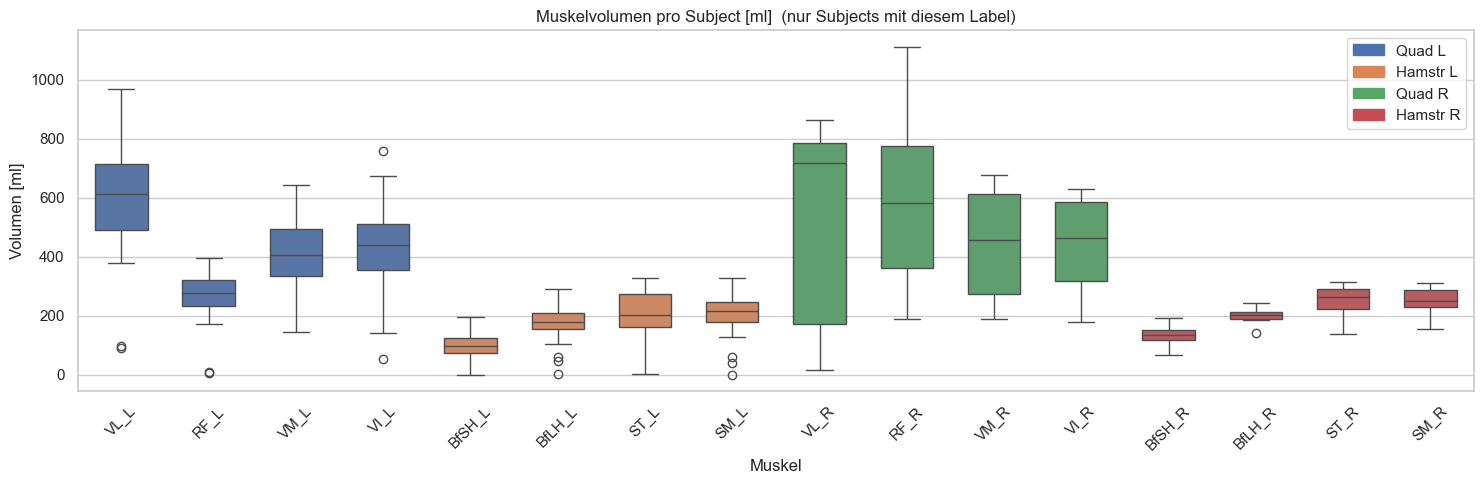

In [9]:
order   = [LABEL_NAMES[l] for l in MUSCLE_LABELS]
palette = {LABEL_NAMES[l]: GROUP_COL[muscle_group(l)] for l in MUSCLE_LABELS}

fig, ax = plt.subplots(figsize=(15, 5))
sns.boxplot(data=vol, x='muscle', y='volume_ml', order=order,
            palette=palette, ax=ax, width=0.6)
ax.set_title('Muskelvolumen pro Subject [ml]  (nur Subjects mit diesem Label)')
ax.set_xlabel('Muskel'); ax.set_ylabel('Volumen [ml]')
ax.tick_params(axis='x', rotation=45)
patches = [mpatches.Patch(color=c, label=g) for g, c in GROUP_COL.items()]
ax.legend(handles=patches, loc='upper right')
plt.tight_layout()
plt.savefig(RESULTS / 'eda_seg_volume_boxplot.png', dpi=150)
plt.show()

**Was man sieht:** Ein Boxplot mit einem Kasten pro Muskel. Die Box zeigt das 25.–75. Perzentil (interquartiler Bereich), der Strich in der Mitte ist der Median, die Whisker zeigen die Gesamtspanne, und Punkte ausserhalb sind Ausreisser. Die Farbe kodiert die Muskelgruppe.

**Was das bedeutet:**
- **Quadrizeps-Muskeln (blau/grün)** sind klar grösser als Hamstrings (orange/rot) — besonders VL ist dominant.
- Die **breiten Boxen** bei VL_L und VI_L zeigen hohe Variabilität zwischen Subjects — das Modell muss lernen, mit unterschiedlich grossen Muskeln umzugehen.
- **BfSH_L** hat nicht nur den kleinsten Median, sondern auch Ausreisser fast bei null — hier lohnt sich eine manuelle Überprüfung dieser Annotations.
- Die rechten Muskeln (VL_R bis SM_R) haben breitere Boxen, weil nur wenige Subjects (n=6–9) vorhanden sind — die Statistik ist weniger stabil.
- **Für den Loss:** Die Imbalance zwischen Muskeln (VL vs. BfSH ~6:1) erfordert ggf. muskelspezifische Gewichtung oder per-class Dice Loss.

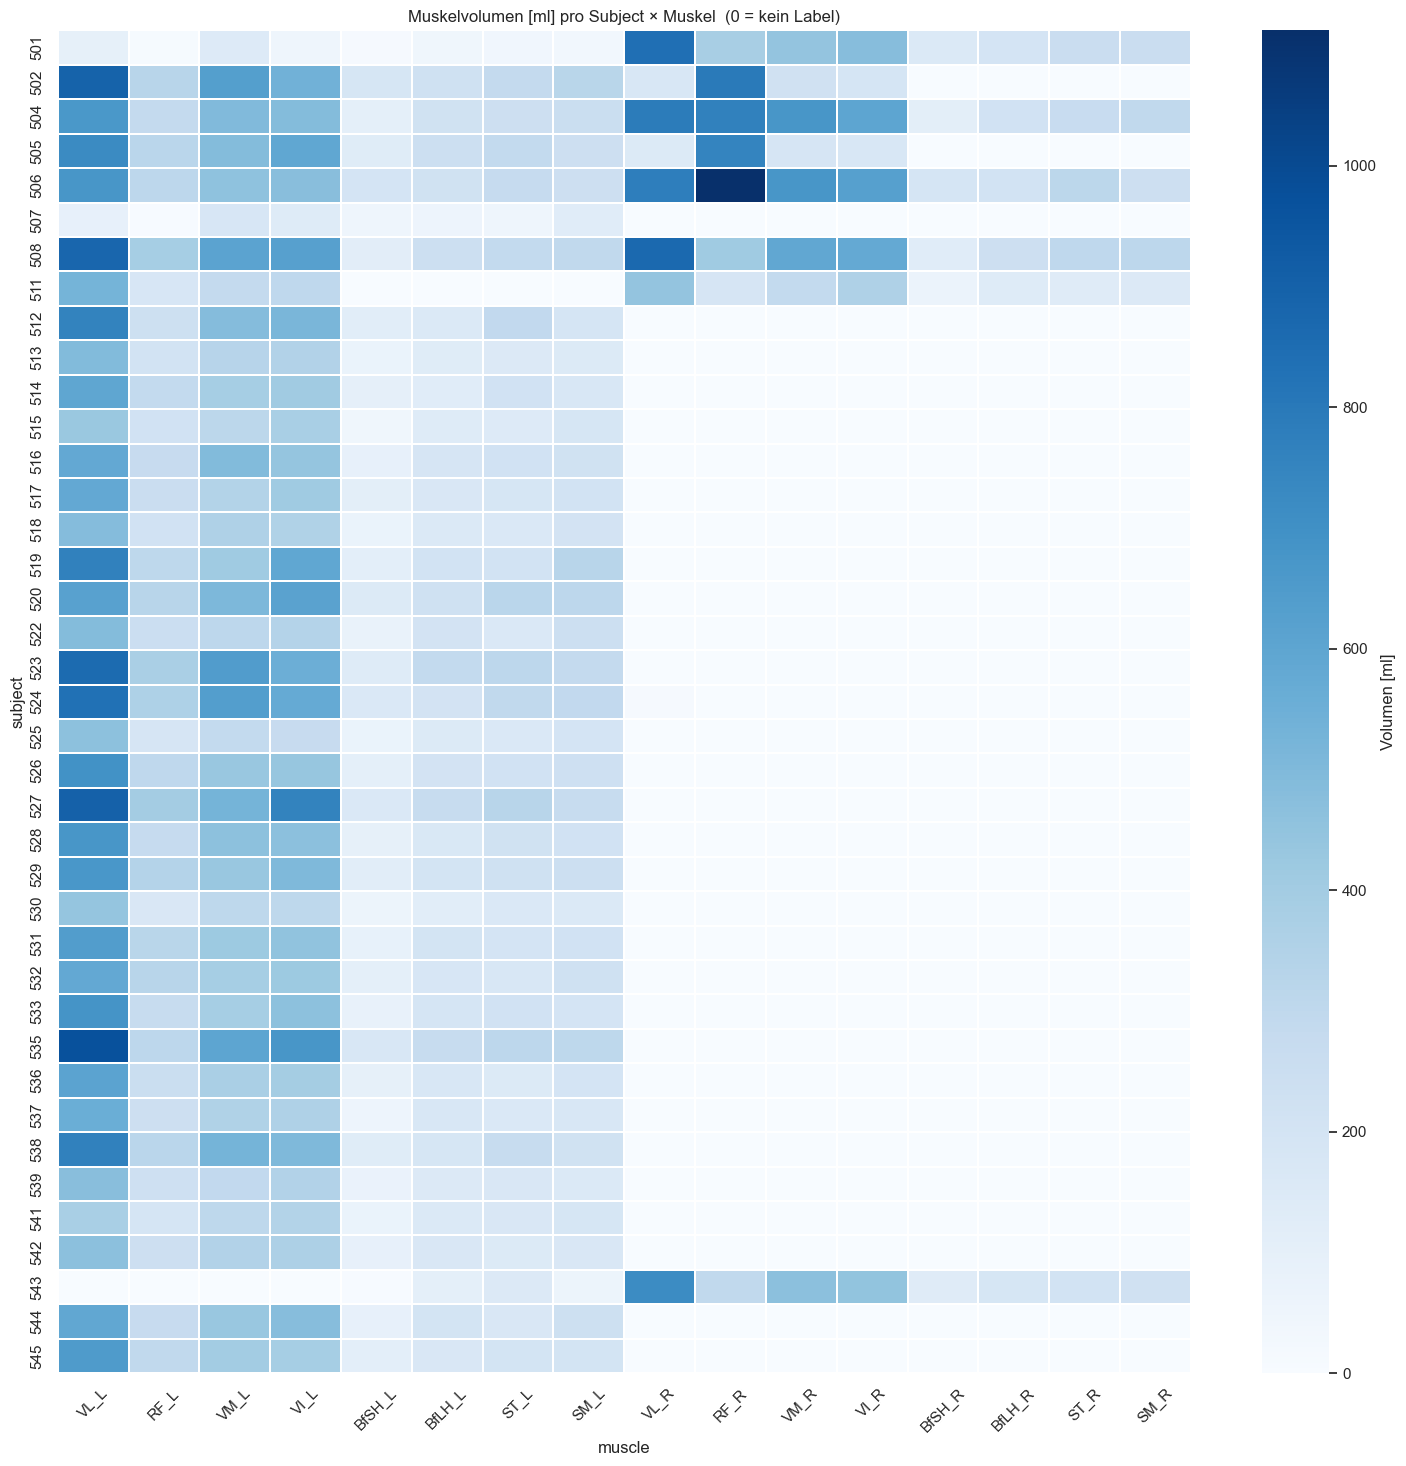

In [10]:
# Heatmap: Volumen (ml) pro Subject × Muskel
avail_muscles = [LABEL_NAMES[l] for l in MUSCLE_LABELS if LABEL_NAMES[l] in vol['muscle'].unique()]
vol_pivot = vol.pivot_table(index='subject', columns='muscle', values='volume_ml', fill_value=0)
vol_pivot = vol_pivot.reindex(columns=[m for m in avail_muscles if m in vol_pivot.columns])

fig, ax = plt.subplots(figsize=(15, max(5, len(vol_pivot) * 0.38)))
sns.heatmap(vol_pivot, ax=ax, cmap='Blues', linewidths=0.3,
            cbar_kws={'label': 'Volumen [ml]'})
ax.set_title('Muskelvolumen [ml] pro Subject × Muskel  (0 = kein Label)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(RESULTS / 'eda_seg_volume_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

**Was man sieht:** Eine Heatmap mit Subjects als Zeilen und Muskeln als Spalten. Die Farbintensität (hellblau bis dunkelblau) zeigt das Muskelvolumen in ml — weiss/leer bedeutet kein Label vorhanden.

**Was das bedeutet:**
- Die **rechten Muskeln-Spalten** (VL_R bis SM_R) sind für die meisten Subjects weiss, was die fehlende Annotation der rechten Seite bestätigt.
- Die **dunklen Felder** bei VL_L zeigen, dass der Vastus Lateralis links bei vielen Subjects gross ist.
- Die **hellen Felder** bei BfSH_L illustrieren, wie klein dieser Muskel im Vergleich ist.
- Man erkennt auch **inter-subject Variabilität**: Manche Subjects haben überall dunklere Felder (insgesamt mehr Muskelmasse), andere durchgehend hellere — das spiegelt natürliche anatomische Unterschiede wider.
- Subject 543 zeigt das unvollständige Label-Set deutlich: Die ersten vier Spalten (Quad links) sind weiss trotz vorhandener Hamstring-Annotation.

---
## 5 · Klassen-Imbalance  (Background vs. Muskeln)

In [11]:
imbal_rows = []
for sid_dir in sorted(MASK_DIR.iterdir()):
    if not sid_dir.is_dir(): continue
    sid = sid_dir.name
    pfiles = [f for f in sid_dir.iterdir()
              if f.suffix == '.gz' and 'right' not in f.name.lower()]
    if not pfiles: continue
    arr = load_mask(pfiles[0])
    if arr is None: continue
    total = arr.size
    n_bg  = int(np.sum(arr == 0))
    n_m   = total - n_bg
    imbal_rows.append(dict(subject=sid, total=total, bg=n_bg,
                           muscle=n_m, muscle_pct=round(100*n_m/total, 4)))

imbal = pd.DataFrame(imbal_rows)
print(f'Muskel-Anteil (primary mask):')
print(f'  Median {imbal["muscle_pct"].median():.3f}%')
print(f'  Min    {imbal["muscle_pct"].min():.3f}%   Max {imbal["muscle_pct"].max():.3f}%')
imbal[['subject','total','bg','muscle','muscle_pct']]

Muskel-Anteil (primary mask):
  Median 1.266%
  Min    0.167%   Max 2.516%


,subject,total,bg,muscle,muscle_pct
0,501,223877632,223280389,597243,0.2668
1,502,223877632,218243881,5633751,2.5164
2,504,223877632,219500648,4376984,1.9551
3,505,228884480,223841645,5042835,2.2032
4,506,228884480,223938065,4946415,2.1611
5,507,228884480,228045965,838515,0.3663
6,508,228884480,224842185,4042295,1.7661
7,511,228884480,227362094,1522386,0.6651
8,512,228884480,225650531,3233949,1.4129
9,513,228884480,226668614,2215866,0.9681


**Was man sieht:** Eine Tabelle mit dem Hintergrund- und Muskelanteil pro Subject — absolut in Voxeln und relativ in Prozent.

**Was das bedeutet:**
- Der **Muskelanteil** liegt zwischen 0.17% und 2.52%, mit einem Median von **1.27%** — d.h. über 98% jedes Bildes ist Hintergrund.
- Subject 501 hat mit 0.27% besonders wenig Muskelanteil — das liegt daran, dass die separate Right-Maske den Quadrizeps rechts abdeckt und dieser in der Primary-Maske fehlt.
- Subject 543 hat mit nur 0.17% den kleinsten Muskelanteil — wegen der fehlenden Quadrizeps-links-Annotation.
- Diese extreme Imbalance ist der **kritischste Faktor** für das Segmentierungsmodell: Ein naiver Classifier, der alles als Hintergrund vorhersagt, hätte ~99% Pixel-Accuracy — daher ist Accuracy als Metrik hier ungeeignet. Stattdessen sollte Dice Score oder IoU verwendet werden.

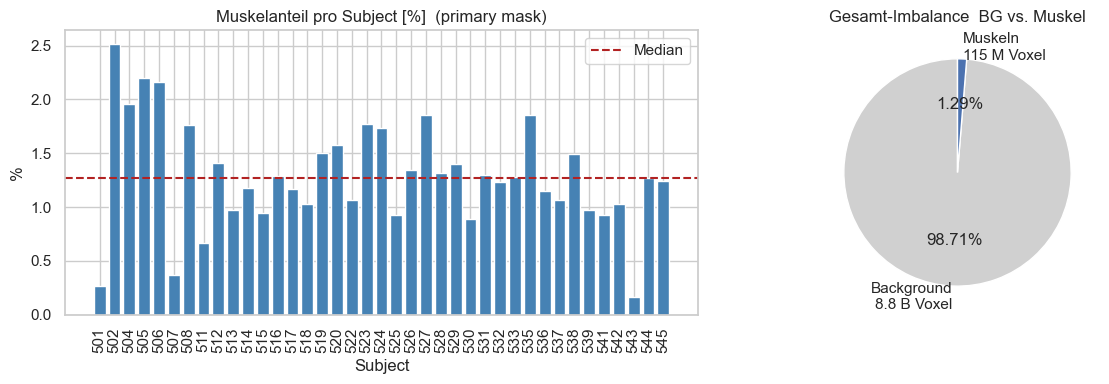


Imbalance-Ratio BG:Muskel = 77:1


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(imbal['subject'], imbal['muscle_pct'], color='steelblue')
axes[0].axhline(imbal['muscle_pct'].median(), color='firebrick', lw=1.5, ls='--', label='Median')
axes[0].set_title('Muskelanteil pro Subject [%]  (primary mask)')
axes[0].set_xlabel('Subject'); axes[0].set_ylabel('%')
axes[0].tick_params(axis='x', rotation=90); axes[0].legend()

total_bg   = imbal['bg'].sum()
total_musc = imbal['muscle'].sum()
axes[1].pie([total_bg, total_musc],
            labels=[f'Background\n{total_bg/1e9:.1f} B Voxel',
                    f'Muskeln\n{total_musc/1e6:.0f} M Voxel'],
            colors=['#d0d0d0','#4C72B0'], autopct='%1.2f%%', startangle=90)
axes[1].set_title('Gesamt-Imbalance  BG vs. Muskel')

plt.tight_layout()
plt.savefig(RESULTS / 'eda_seg_classimbalance.png', dpi=150)
plt.show()

print(f'\nImbalance-Ratio BG:Muskel = {total_bg/total_musc:.0f}:1')

**Was man sieht:** Links ein Balkendiagramm mit dem Muskelanteil in % pro Subject (rote gestrichelte Linie = Median); rechts ein Tortendiagramm der Gesamt-Imbalance zwischen Hintergrund und Muskel-Voxeln über alle Subjects.

**Was das bedeutet:**
- Das **Balkendiagramm** zeigt die Variabilität zwischen Subjects: Die meisten liegen zwischen 1–2%, einige Ausreisser (z.B. Subject 543, 507) haben deutlich weniger Muskelanteil. Diese Subjects könnten im Training schwerer sein.
- Das **Tortendiagramm** macht die Imbalance visuell eindrücklich: Nur ein winziges Segment (Muskeln) steht einem riesigen Rest (Hintergrund) gegenüber. Das **Verhältnis ist 77:1** — auf jeden Muskel-Voxel kommen 77 Hintergrund-Voxel.
- **Konsequenzen für das Training:**
  - Dice Loss oder Focal Loss statt Standard Cross-Entropy verwenden
  - Patch-basiertes Sampling: nur Patches mit Muskelinhalt trainieren, um leere Patches zu überspringen
  - Oder Class Weights: Hintergrund mit 1/77 gewichten relativ zu Muskeln

---
## 6 · Slice-Coverage – wie viele Schichten enthält jedes Label?

In [13]:
cov_rows = []
for sid_dir in sorted(MASK_DIR.iterdir()):
    if not sid_dir.is_dir(): continue
    sid = sid_dir.name
    files = sorted(f for f in sid_dir.iterdir() if f.suffix == '.gz')

    merged = None
    n_slices = None
    for fp in files:
        arr = load_mask(fp)
        if arr is None: continue
        if merged is None:
            merged = arr.copy(); n_slices = arr.shape[2]
        else:
            fg = arr > 0; merged[fg] = arr[fg]

    if merged is None: continue

    for l in MUSCLE_LABELS:
        per_slice = np.any(merged == l, axis=(0, 1))
        n_with    = int(per_slice.sum())
        if n_with > 0:
            zidx = np.where(per_slice)[0]
            cov_rows.append(dict(
                subject=sid, label=l,
                muscle=LABEL_NAMES[l],
                group=muscle_group(l),
                n_slices_total=n_slices,
                n_slices_label=n_with,
                coverage_pct=round(100 * n_with / n_slices, 1),
                z_min=int(zidx.min()), z_max=int(zidx.max()),
                z_span=int(zidx.max() - zidx.min() + 1)
            ))

cov = pd.DataFrame(cov_rows)
print('Coverage-Statistik pro Muskel:')
cov.groupby(['label','muscle'])['coverage_pct'].agg(
    n='count', mean='mean', std='std', min='min', max='max'
).round(1)

Coverage-Statistik pro Muskel:


,,n,mean,std,min,max
label,muscle,,,,,
1,VL_L,38,24.8,5.3,2.6,31.2
2,RF_L,38,24.0,5.4,2.5,29.7
3,VM_L,38,24.2,4.7,5.3,30.0
4,VI_L,38,26.0,5.4,2.6,30.6
5,BfSH_L,39,18.0,5.4,0.2,22.8
6,BfLH_L,39,19.8,5.5,0.2,25.9
7,ST_L,39,22.4,6.1,0.2,28.0
8,SM_L,39,18.9,5.5,0.2,24.1
9,VL_R,9,24.9,5.9,10.2,29.2


**Was man sieht:** Eine Tabelle mit der Slice-Coverage pro Muskel: wie viele Subjects haben diesen Muskel (n), welcher Prozentsatz der Schichten enthält den Muskel im Durchschnitt, sowie Minimum und Maximum.

**Was das bedeutet:**
- **Quadrizeps-Muskeln** (VL, RF, VM, VI) decken ca. **24–26%** der Schichten ab — diese Muskeln erstrecken sich über einen grösseren Z-Bereich.
- **Hamstrings** (BfSH, BfLH, ST, SM) decken nur **18–22%** der Schichten ab — sie sind in Z-Richtung kompakter.
- Die hohe **Standardabweichung** (~5%) zeigt, dass der Muskelbereich von Subject zu Subject erheblich variiert.
- Die **sehr tiefen Minimalwerte** (0.2%) bei den Hamstrings deuten auf Subjects hin, bei denen nur sehr wenige Schichten annotiert wurden — möglicherweise fehlerhafte oder unvollständige Masken.
- **Praktische Konsequenz:** Da Muskeln nur in ~20–26% der Schichten vorkommen, könnte man den Z-Bereich auf relevante Schichten begrenzen und so ca. 75% der leeren Schichten überspringen — das spart Speicher und Rechenzeit.

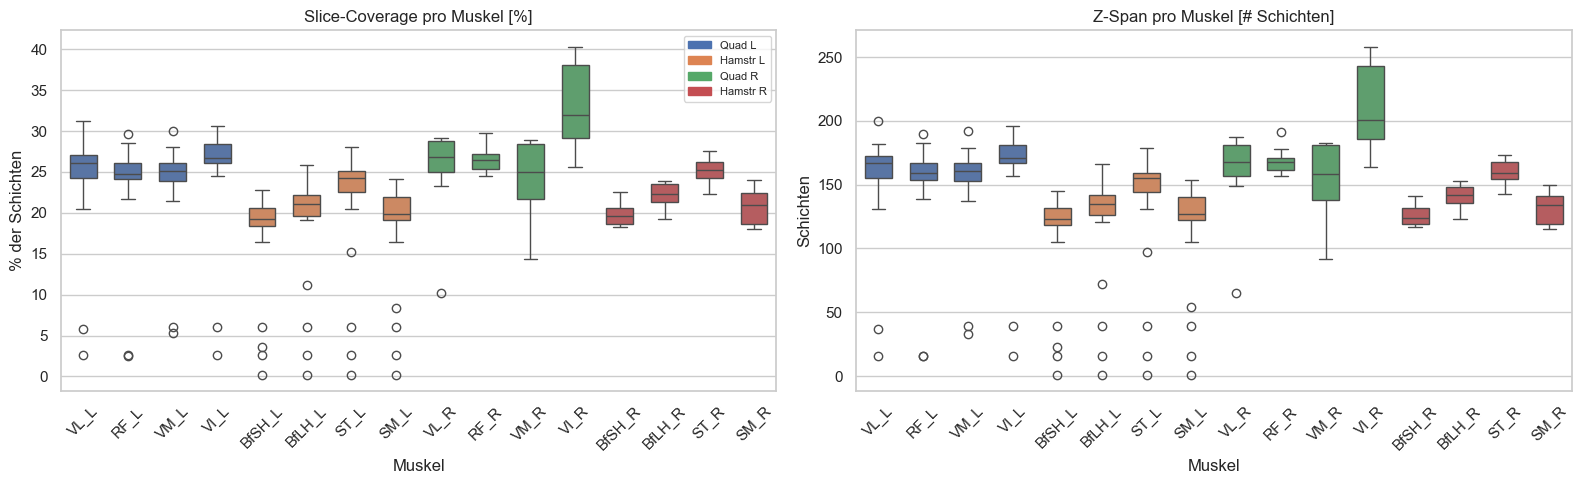

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

order_avail = [LABEL_NAMES[l] for l in MUSCLE_LABELS if LABEL_NAMES[l] in cov['muscle'].unique()]
palette_avail = {m: GROUP_COL[muscle_group(l)]
                 for l in MUSCLE_LABELS for m in [LABEL_NAMES[l]] if m in order_avail}

sns.boxplot(data=cov, x='muscle', y='coverage_pct', order=order_avail,
            palette=palette_avail, ax=axes[0], width=0.6)
axes[0].set_title('Slice-Coverage pro Muskel [%]')
axes[0].set_xlabel('Muskel'); axes[0].set_ylabel('% der Schichten')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(data=cov, x='muscle', y='z_span', order=order_avail,
            palette=palette_avail, ax=axes[1], width=0.6)
axes[1].set_title('Z-Span pro Muskel [# Schichten]')
axes[1].set_xlabel('Muskel'); axes[1].set_ylabel('Schichten')
axes[1].tick_params(axis='x', rotation=45)

patches = [mpatches.Patch(color=c, label=g) for g, c in GROUP_COL.items()]
axes[0].legend(handles=patches, fontsize=8)

plt.tight_layout()
plt.savefig(RESULTS / 'eda_seg_slice_coverage.png', dpi=150)
plt.show()

**Was man sieht:** Zwei nebeneinander liegende Boxplots — links die Slice-Coverage in Prozent, rechts der Z-Span (Anzahl Schichten, über die sich der Muskel erstreckt) — je Muskel.

**Was das bedeutet:**
- Der **linke Boxplot (Coverage %)** zeigt, dass Quadrizeps-Muskeln mehr Schichten abdecken als Hamstrings. VI_R hat mit ~33% die höchste Coverage — möglicherweise weil dieser Muskel im rechten Bild weiter reicht oder die Annotation grosszügiger war.
- Der **rechte Boxplot (Z-Span)** zeigt die absolute Anzahl Schichten, über die sich der Muskel erstreckt. Da alle Subjects ~640 Schichten haben, ist Z-Span proportional zu Coverage %, aber wichtig um absolute Zahlen zu sehen.
- Die **breiten Boxen** bei den linken Muskeln (n=38–39) zeigen die inter-individuelle Variabilität des Muskel-Verlaufs im Scan.
- Die **engen Boxen** bei den rechten Muskeln (n=6–9) sehen kleiner aus, sind aber wegen weniger Datenpunkten statistisch weniger aussagekräftig.
- **Implikation:** Beim Slicing für 2D-Training sollte man die z-Koordinaten pro Subject dynamisch aus der Maske bestimmen, statt einen festen Z-Bereich zu wählen.

---
## 7 · Label-Imbalance zwischen den Muskeln (relative Grösse)

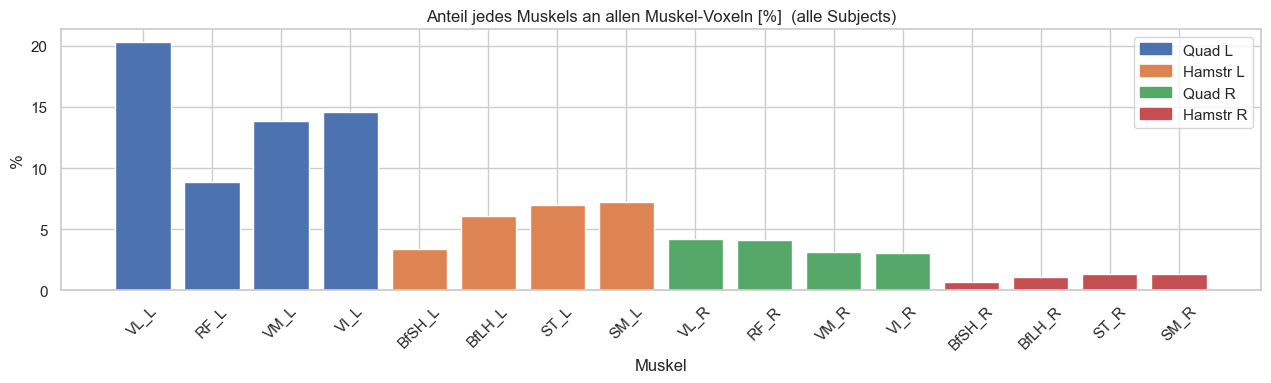

muscle   voxels  pct_of_all_muscle
  VL_L 27243402              20.33
  RF_L 11850860               8.84
  VM_L 18526745              13.82
  VI_L 19561264              14.60
BfSH_L  4559807               3.40
BfLH_L  8139821               6.07
  ST_L  9337882               6.97
  SM_L  9623936               7.18
  VL_R  5595460               4.17
  RF_R  5518955               4.12
  VM_R  4171185               3.11
  VI_R  4068339               3.04
BfSH_R   938626               0.70
BfLH_R  1397731               1.04
  ST_R  1745358               1.30
  SM_R  1744906               1.30


In [15]:
# Gesamtvoxel pro Muskel (alle Subjects summiert)
total_per_muscle = vol.groupby(['label','muscle','group'])['voxels'].sum().reset_index()
total_per_muscle = total_per_muscle.sort_values('label')
total_per_muscle['pct_of_all_muscle'] = (
    100 * total_per_muscle['voxels'] / total_per_muscle['voxels'].sum()
).round(2)

fig, ax = plt.subplots(figsize=(13, 4))
colors = [GROUP_COL[g] for g in total_per_muscle['group']]
bars = ax.bar(total_per_muscle['muscle'], total_per_muscle['pct_of_all_muscle'],
              color=colors, edgecolor='white')
ax.set_title('Anteil jedes Muskels an allen Muskel-Voxeln [%]  (alle Subjects)')
ax.set_xlabel('Muskel'); ax.set_ylabel('%')
ax.tick_params(axis='x', rotation=45)
patches = [mpatches.Patch(color=c, label=g) for g, c in GROUP_COL.items()]
ax.legend(handles=patches)
plt.tight_layout()
plt.savefig(RESULTS / 'eda_seg_label_share.png', dpi=150)
plt.show()

print(total_per_muscle[['muscle','voxels','pct_of_all_muscle']].to_string(index=False))

**Was man sieht:** Ein Balkendiagramm, das den prozentualen Anteil jedes Muskels an der Gesamtzahl aller Muskel-Voxel über alle Subjects zeigt. Die Farbe kodiert die Muskelgruppe.

**Was das bedeutet:**
- **VL_L und VI_L** dominieren klar — zusammen machen die Quadrizeps-Muskeln den Grossteil aller Muskel-Voxel aus.
- **BfSH_L** ist der kleinste Balken — dieser Muskel ist am stärksten unterrepräsentiert unter den Muskelklassen.
- Die rechten Muskeln (grün/rot) haben insgesamt kleinere Balken, weil sie nur bei wenigen Subjects annotiert sind — es sind also strukturell weniger Daten vorhanden, nicht unbedingt kleinere Muskeln.
- Diese **Label-Imbalance zwischen Muskeln** kommt zusätzlich zur BG/Muskel-Imbalance (77:1). Das bedeutet: Das Modell wird gut im Segmentieren von VL lernen, aber BfSH wird schwieriger sein. Per-class Dice Loss ist daher besonders wichtig, da er jeden Muskel gleich stark gewichtet unabhängig von seiner Grösse.

---
## 8 · Zusammenfassung – relevante Kennzahlen für Segmentierungsmodell

In [16]:
n_bi = (id_table['bilateral'] == 'Ja').sum()

print('=' * 60)
print('DATASET-ÜBERSICHT')
print('=' * 60)
print(f'  Subjects gesamt          : {len(sids)}')
print(f'  Davon bilateral annotiert: {n_bi}')
print(f'  Davon nur links          : {len(sids) - n_bi}')
print()
print('BILDGEOMETRIE')
print(f'  Voxelgrösse (typisch)    : 0.65 × 0.65 × 2.0 mm')
print(f'  In-plane Auflösung       : 704 × 508 Voxel')
print(f'  Anzahl Schichten (Z)     : {shapes["Z"].min():.0f} – {shapes["Z"].max():.0f}')
print()
print('KLASSEN')
print(f'  Klassen gesamt (inkl. BG): 17  (BG + 8 links + 8 rechts)')
print(f'  Imbalance-Ratio BG:Muskel: {total_bg/total_musc:.0f}:1')
print(f'  Muskel-Anteil (Median)   : {imbal["muscle_pct"].median():.3f}% der Voxel')
print()
print('VOLUMEN PRO MUSKEL (Median über alle Subjects mit diesem Label)')
for _, row in stats.iterrows():
    print(f'  {row["muscle"]:8s}  {row["median"]:6.1f} ml   '
          f'[{row["min"]:.0f} – {row["max"]:.0f}]   (n={int(row["n"])} Subjects)')
print('=' * 60)

DATASET-ÜBERSICHT
  Subjects gesamt          : 39
  Davon bilateral annotiert: 9
  Davon nur links          : 30

BILDGEOMETRIE
  Voxelgrösse (typisch)    : 0.65 × 0.65 × 2.0 mm
  In-plane Auflösung       : 704 × 508 Voxel
  Anzahl Schichten (Z)     : 626 – 640

KLASSEN
  Klassen gesamt (inkl. BG): 17  (BG + 8 links + 8 rechts)
  Imbalance-Ratio BG:Muskel: 77:1
  Muskel-Anteil (Median)   : 1.266% der Voxel

VOLUMEN PRO MUSKEL (Median über alle Subjects mit diesem Label)
  VL_L       614.4 ml   [92 – 971]   (n=38 Subjects)
  RF_L       279.0 ml   [6 – 396]   (n=38 Subjects)
  VM_L       406.2 ml   [146 – 644]   (n=38 Subjects)
  VI_L       439.2 ml   [53 – 760]   (n=38 Subjects)
  BfSH_L      96.7 ml   [0 – 197]   (n=39 Subjects)
  BfLH_L     179.7 ml   [2 – 290]   (n=39 Subjects)
  ST_L       203.0 ml   [1 – 328]   (n=39 Subjects)
  SM_L       215.6 ml   [1 – 329]   (n=39 Subjects)
  VL_R       718.5 ml   [15 – 866]   (n=9 Subjects)
  RF_R       583.5 ml   [189 – 1112]   (n=8 Subjects)

**Was man sieht:** Eine kompakte Übersicht der wichtigsten Kennzahlen des Datensatzes — Subjects, Bildgeometrie, Klassenverteilung und Volumina pro Muskel.

**Was das bedeutet — die 5 wichtigsten Erkenntnisse für das Segmentierungsmodell:**

1. **Wenig Daten (n=39):** Data Augmentation ist essenziell (z.B. Flipping, Rotation, Intensity-Jitter). Cross-Validation oder Leave-One-Out empfehlenswert wegen kleiner Datenmenge.

2. **Asymmetrie links/rechts:** 30 Subjects nur links annotiert → entweder nur linke Seite trainieren (n=39) oder bilateral mit gespiegelten Daten (links als rechts augmentieren), um mehr Daten zu gewinnen.

3. **Extreme Klassen-Imbalance 77:1:** Dice Loss oder Focal Loss zwingend notwendig. Pixel-Accuracy ist als Metrik wertlos — immer Dice Score oder IoU pro Klasse berichten.

4. **Einheitliche Geometrie:** Kein Resampling nötig. Aber die anisotrope Auflösung (0.65 mm in-plane vs. 2.0 mm durch Schichten) spricht für einen 2D-Segmentierungsansatz (Slice-by-Slice) oder anisotrope 3D-Kernel.

5. **Unvollständige Subjects (502, 505, 524, 543):** Diese Subjects müssen entweder ausgeschlossen oder mit maskiertem Loss behandelt werden (nur vorhandene Labels trainieren, fehlende ignorieren).